In [ ]:
!pip -q install kagglehub
import kagglehub

DATASET_SLUG = "saidakbarp/17-category-flowers"

path = kagglehub.dataset_download(DATASET_SLUG)
print("Downloaded to:", path)

Using Colab cache for faster access to the '17-category-flowers' dataset.
Downloaded to: /kaggle/input/17-category-flowers


In [ ]:
import os, tarfile

tgz_path = os.path.join(path, "17flowers.tgz")
extract_dir = "/content/17flowers"
os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(tgz_path, "r:") as tar:
    tar.extractall(extract_dir)

jpg_dir = "/content/17flowers/jpg"
print("Extracted to:", jpg_dir)
print("file numbers:", len(os.listdir(jpg_dir)))

/tmp/ipykernel_1277/2949404212.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


Extracted to: /content/17flowers/jpg
file numbers: 1362


In [ ]:
import os, tarfile

tgz_path = os.path.join(path, "17flowers.tgz")
extract_dir = "/content/17flowers"
os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(tgz_path, "r:") as tar:
    tar.extractall(extract_dir)

jpg_dir = "/content/17flowers/jpg"
print("Extracted to:", jpg_dir)
print("Total files:", len(os.listdir(jpg_dir)))

/tmp/ipykernel_683/831591821.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


Extracted to: /content/17flowers/jpg
Total files: 1362


In [ ]:
import shutil

FLOWER_NAMES = ["Daffodil", "Snowdrop", "LilyValley", "Bluebell", "Crocus",
                "Iris", "Tigerlily", "Tulip", "Fritillary", "Sunflower",
                "Daisy", "ColtsFoot", "Dandelion", "Cowslip", "Buttercup",
                "Windflower", "Pansy"]
IMAGES_PER_CLASS = 80

data_dir = "/content/flowers_structured"
if os.path.exists(data_dir):
    shutil.rmtree(data_dir)
os.makedirs(data_dir)

jpg_files = sorted(f for f in os.listdir(jpg_dir) if f.lower().endswith(".jpg"))
assert len(jpg_files) == len(FLOWER_NAMES) * IMAGES_PER_CLASS, \
    f"Found {len(jpg_files)} images, expected {len(FLOWER_NAMES) * IMAGES_PER_CLASS}"

for idx, fname in enumerate(jpg_files):
    class_name = FLOWER_NAMES[idx // IMAGES_PER_CLASS]
    class_dir = os.path.join(data_dir, class_name)
    os.makedirs(class_dir, exist_ok=True)
    shutil.copy(os.path.join(jpg_dir, fname), os.path.join(class_dir, fname))

print("Structured dataset at:", data_dir)
for name in sorted(os.listdir(data_dir)):
    print(name, "-", len(os.listdir(os.path.join(data_dir, name))), "images")

Structured dataset at: /content/flowers_structured
Bluebell - 80 images
Buttercup - 80 images
ColtsFoot - 80 images
Cowslip - 80 images
Crocus - 80 images
Daffodil - 80 images
Daisy - 80 images
Dandelion - 80 images
Fritillary - 80 images
Iris - 80 images
LilyValley - 80 images
Pansy - 80 images
Snowdrop - 80 images
Sunflower - 80 images
Tigerlily - 80 images
Tulip - 80 images
Windflower - 80 images


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

In [ ]:
image_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)
print("Number of classes:", num_classes)

Found 1360 files belonging to 17 classes.
Using 1088 files for training.
Found 1360 files belonging to 17 classes.
Using 272 files for validation.
['Bluebell', 'Buttercup', 'ColtsFoot', 'Cowslip', 'Crocus', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'LilyValley', 'Pansy', 'Snowdrop', 'Sunflower', 'Tigerlily', 'Tulip', 'Windflower']
Number of classes: 17


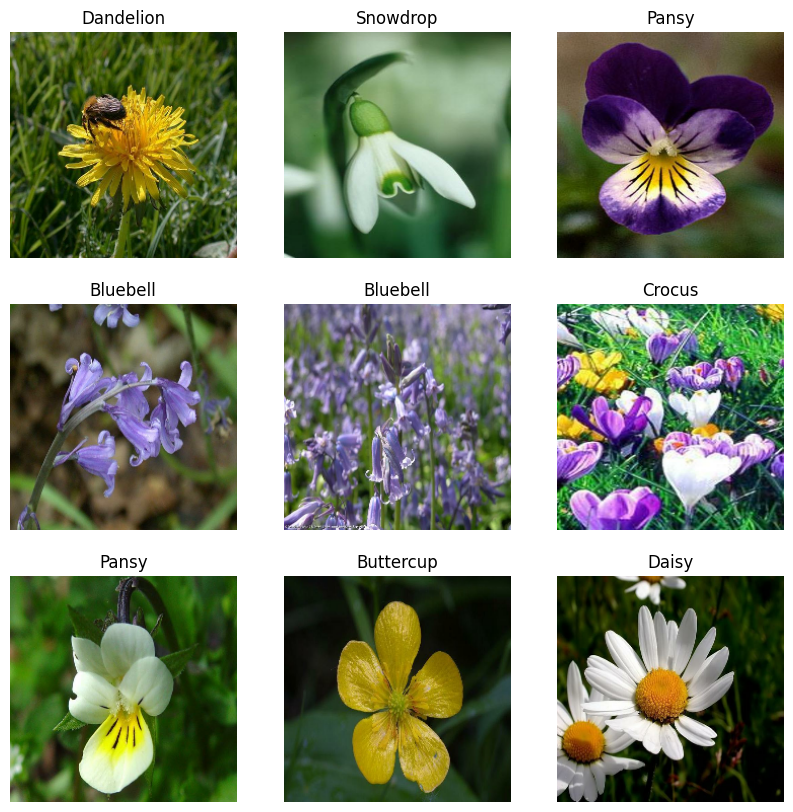

In [8]:
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (preprocess(x), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess(x), y)).prefetch(AUTOTUNE)

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

feature_model = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dense(num_classes, activation="softmax"),
])
feature_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,145 (9.25 MB)

 Trainable params: 166,161 (649.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
feature_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )

In [10]:
history = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 38s 586ms/step - accuracy: 0.6186 - loss: 1.3607 - val_accuracy: 0.9118 - val_loss: 0.3487
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9274 - loss: 0.2948 - val_accuracy: 0.9669 - val_loss: 0.1672
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9706 - loss: 0.1501 - val_accuracy: 0.9853 - val_loss: 0.1089
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9926 - loss: 0.0827 - val_accuracy: 0.9853 - val_loss: 0.1008
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.9972 - loss: 0.0461 - val_accuracy: 0.9890 - val_loss: 0.0470
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9991 - loss: 0.0334 - val_accuracy: 0.9890 - val_loss: 0.0472
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 1.0000 - loss: 0.0237 - val_accuracy: 0.9890 - val_loss: 0.0504
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 1.0000 - loss: 0.0180 - val_accuracy: 0.9853 -

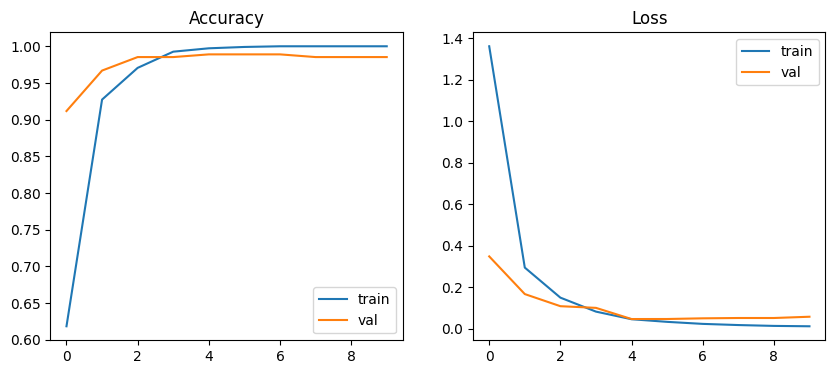

In [11]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()
plt.show()

In [12]:
feature_model.save("Flowers_Feature.h5")

Saving bluebells-close-up-wtml-1024791-web-upload.jpg to bluebells-close-up-wtml-1024791-web-upload.jpg


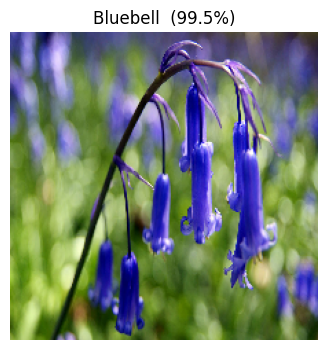

Bluebell                   99.5%
Snowdrop                    0.3%
Tigerlily                   0.1%


In [13]:
from google.colab import files
from tensorflow.keras.preprocessing import image as kimage

uploaded = files.upload()

for fname in uploaded.keys():
    img = kimage.load_img(fname, target_size=image_size)
    x = kimage.img_to_array(img)
    x = preprocess(np.expand_dims(x, axis=0))

    probs = feature_model.predict(x, verbose=0)[0]
    top3 = probs.argsort()[-3:][::-1]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[top3[0]]}  ({probs[top3[0]]*100:.1f}%)")
    plt.show()

    for i in top3:
        print(f"{class_names[i]:<25} {probs[i]*100:5.1f}%")